# Task 1: Statistical Analysis – Mean, Median & Mode

## Objective

Calculate the Mean, Median, and Mode of the Sales variable and interpret what each statistical measure tells us about the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xlrd as xl


pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")
df = pd.read_excel("../dataset/super_store.xls")

print("Excel file loaded successfully!")

Libraries imported successfully!
Excel file loaded successfully!


In [2]:
# Check the Sales column
df["Sales"].head()

0     16.448
1      3.540
2     11.784
3    272.736
4     19.536
Name: Sales, dtype: float64

In [3]:
# Calculate Mean, Median, and Mode of Sales

mean_sales = df["Sales"].mean()
median_sales = df["Sales"].median()
mode_sales = df["Sales"].mode()

# Display the statistical results clearly

print("Statistical Analysis of Sales")
print("-" * 35)
print(f"Mean   : {mean_sales:.2f}")
print(f"Median : {median_sales:.2f}")
print(f"Mode   : {mode_sales.iloc[0]:.2f}")

Statistical Analysis of Sales
-----------------------------------
Mean   : 228.23
Median : 53.91
Mode   : 12.96


## Interpretation

- **Mean:** The mean represents the average sales value per order. It provides an overall measure of the typical sales value across the dataset.

- **Median:** The median represents the middle sales value when all orders are arranged in ascending order. It is useful for understanding the central value without being strongly affected by extreme sales values.

- **Mode:** The mode represents the sales value that occurs most frequently in the dataset. It helps identify the most commonly occurring sales amount.

### Conclusion

The comparison between the mean and median helps us understand the distribution of sales values. If the mean is significantly higher than the median, it may indicate that some high-value orders are influencing the average.

In [4]:
# Check the number of unique Sales values
df["Sales"].nunique()

6161

# Task 2: Variance & Standard Deviation

## Objective

Calculate the variance and standard deviation of the Sales variable and explain what the standard deviation indicates about the spread of the data.

In [5]:
# Calculate Variance and Standard Deviation of Sales

variance_sales = df["Sales"].var()
std_sales = df["Sales"].std()

print("Variance of Sales:", variance_sales)
print("Standard Deviation of Sales:", std_sales)

Variance of Sales: 384284.488765325
Standard Deviation of Sales: 619.9068387792838


In [6]:
# Display the statistical results clearly

print("Variance & Standard Deviation of Sales")
print("-" * 45)
print(f"Variance          : {variance_sales:.2f}")
print(f"Standard Deviation: {std_sales:.2f}")

Variance & Standard Deviation of Sales
---------------------------------------------
Variance          : 384284.49
Standard Deviation: 619.91


In [7]:
# Compare standard deviation with the mean

std_to_mean_ratio = std_sales / mean_sales

print(f"Standard Deviation / Mean: {std_to_mean_ratio:.2f}")

Standard Deviation / Mean: 2.72


## Interpretation

- **Variance:** The variance of Sales is **384,284.49**. Variance measures how widely the Sales values are distributed around the mean. The relatively large variance indicates substantial variability in the Sales data.

- **Standard Deviation:** The standard deviation of Sales is **619.91**. This indicates that the Sales values have a considerable spread around the mean Sales value of **228.23**.

- **Standard Deviation / Mean:** The standard deviation is approximately **2.72 times the mean**, indicating that the Sales data has high variability. This is consistent with the large difference between the mean (**228.23**) and median (**53.91**) observed in Task 1.

### Conclusion

The Sales dataset has substantial variation in order values. The high standard deviation indicates that Sales values are widely spread around the mean, with some orders having considerably higher sales values than others. This high variability is also consistent with the right-skewed distribution suggested by the difference between the mean and median.

# Task 3: Correlation & Probability Basics

## Objective

Analyze the relationship between two numerical variables using correlation and calculate a simple real-world probability using the Superstore dataset.

In [8]:
# Calculate correlation between Sales and Profit

sales_profit_correlation = df["Sales"].corr(df["Profit"])

print("Correlation between Sales and Profit:", sales_profit_correlation)

Correlation between Sales and Profit: 0.48145972301923856


In [9]:
# Display the correlation result clearly

print("Correlation Analysis")
print("-" * 35)
print(f"Sales vs Profit Correlation: {sales_profit_correlation:.2f}")

Correlation Analysis
-----------------------------------
Sales vs Profit Correlation: 0.48


In [10]:
# Interpret the correlation

if sales_profit_correlation > 0.7:
    relationship = "Strong positive"
elif sales_profit_correlation > 0.3:
    relationship = "Moderate positive"
elif sales_profit_correlation > 0:
    relationship = "Weak positive"
elif sales_profit_correlation < -0.7:
    relationship = "Strong negative"
elif sales_profit_correlation < -0.3:
    relationship = "Moderate negative"
elif sales_profit_correlation < 0:
    relationship = "Weak negative"
else:
    relationship = "No linear relationship"

print("Relationship:", relationship)

Relationship: Moderate positive


In [11]:
# Count orders in the Technology category

technology_orders = (df["Category"] == "Technology").sum()
total_orders = len(df)

print("Technology Orders:", technology_orders)
print("Total Orders:", total_orders)

Technology Orders: 1865
Total Orders: 10194


In [12]:
# Calculate probability of selecting a Technology order

probability_technology = technology_orders / total_orders

print("Probability of selecting a Technology order:", probability_technology)
print(f"Probability as percentage: {probability_technology * 100:.2f}%")

Probability of selecting a Technology order: 0.18295075534628213
Probability as percentage: 18.30%


In [13]:
# Display probability analysis clearly

print("Probability Analysis")
print("-" * 35)
print(f"Technology Orders : {technology_orders}")
print(f"Total Orders      : {total_orders}")
print(f"Probability       : {probability_technology:.4f}")
print(f"Percentage        : {probability_technology * 100:.2f}%")

Probability Analysis
-----------------------------------
Technology Orders : 1865
Total Orders      : 10194
Probability       : 0.1830
Percentage        : 18.30%


## Task 3 Interpretation

### Correlation

The correlation coefficient between **Sales and Profit is 0.4815**. This indicates a **moderate positive relationship** between the two variables.

This means that higher Sales values tend to be associated with higher Profit values. However, the relationship is not strong enough to conclude that Sales alone determines Profit. Other factors such as Discount, Category, Quantity, and product characteristics may also influence Profit.

### Probability

There are **1,865 Technology orders** out of **10,194 total orders**.

The probability of randomly selecting a Technology order is:

**Probability = 1,865 / 10,194 = 0.183**

Therefore, the probability is approximately **18.3%**.

This means that if one order is selected randomly from the dataset, there is approximately an **18.3% chance** that the order belongs to the Technology category.

### Conclusion

The analysis shows a moderate positive relationship between Sales and Profit, while Technology orders represent approximately 18.3% of all orders in the dataset.

# Task 4: Outlier Detection

## Objective

Identify potential outliers in the Sales variable using the Interquartile Range (IQR) method and explain how outliers can affect data analysis.

In [14]:
# Calculate Q1, Q3, and IQR for Sales

Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 17.22
Q3: 209.5
IQR: 192.28


In [15]:
# Calculate lower and upper bounds for detecting outliers

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -271.20000000000005
Upper Bound: 497.92


In [16]:
# Identify potential Sales outliers

outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 1183


In [17]:
# Display the identified Sales outliers

outliers[["Sales", "Profit", "Category", "Sub-Category"]].head(20)

,Sales,Profit,Category,Sub-Category
5,2573.820,746.4078,Furniture,Chairs
8,609.980,274.4910,Office Supplies,Binders
12,755.960,204.1092,Technology,Phones
22,545.940,87.3504,Furniture,Chairs
29,572.580,34.3548,Office Supplies,Storage
30,1325.850,238.6530,Office Supplies,Storage
31,646.740,258.6960,Technology,Accessories
43,1067.940,224.2674,Furniture,Chairs
59,699.930,181.9818,Technology,Phones
102,1256.220,75.3732,Furniture,Tables


In [18]:
# Summary of outlier detection

print("Outlier Detection Summary")
print("-" * 40)
print(f"Q1                 : {Q1:.2f}")
print(f"Q3                 : {Q3:.2f}")
print(f"IQR                : {IQR:.2f}")
print(f"Lower Bound        : {lower_bound:.2f}")
print(f"Upper Bound        : {upper_bound:.2f}")
print(f"Number of Outliers : {len(outliers)}")
# Calculate percentage of potential outliers
outlier_percentage = (len(outliers) / len(df)) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

Outlier Detection Summary
----------------------------------------
Q1                 : 17.22
Q3                 : 209.50
IQR                : 192.28
Lower Bound        : -271.20
Upper Bound        : 497.92
Number of Outliers : 1183
Outlier Percentage: 11.60%


## Interpretation

The IQR method was used to identify potential outliers in the Sales variable.

The first quartile (Q1) is **17.22** and the third quartile (Q3) is **209.50**, giving an IQR of **192.28**. Using the 1.5 × IQR rule, the lower bound is **-271.20** and the upper bound is **497.92**.

Therefore, Sales values greater than **497.92** are considered potential outliers.

The analysis identified **1,183 potential outliers**, which represents approximately **11.60%** of the 10,194 orders.

The identified outliers are primarily high-value Sales transactions. For example, the displayed records include Sales values such as **2,573.82, 609.98, 755.96, 545.94, and 1,325.85**.

### Effect of Outliers on Data Analysis

Outliers can have a significant effect on statistical measures such as the mean and standard deviation. They can also influence correlation analysis and the appearance of visualizations.

However, these potential outliers should not automatically be removed. In a business dataset, a high Sales value may represent a legitimate large customer order rather than an error. Therefore, the outliers should be investigated before deciding whether they should be removed or retained.

### Conclusion

The IQR analysis shows that the Sales dataset contains a considerable number of high-value transactions. These potential outliers help explain why the mean Sales value (**228.23**) is substantially higher than the median (**53.91**). The outliers should be retained unless further investigation confirms that they are incorrect or invalid records.

## Task 5: Matplotlib Visualizations

Matplotlib was used to create five different visualizations from the Superstore dataset: a line chart, bar chart, pie chart, histogram, and scatter plot.

These visualizations help analyze sales trends, category performance, order distribution, sales distribution, and the relationship between Sales and Profit.

In [19]:
# Create folders for saving Matplotlib visualizations

import os

os.makedirs("../visualizations/matplotlib", exist_ok=True)

print("Matplotlib visualization folder is ready.")

Matplotlib visualization folder is ready.


In [20]:
# Convert Order Date to datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Calculate monthly sales

monthly_sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

Order Date
2023-01-01    14518.055
2023-02-01     4519.892
2023-03-01    56933.909
2023-04-01    28295.345
2023-05-01    26319.767
Freq: MS, Name: Sales, dtype: float64

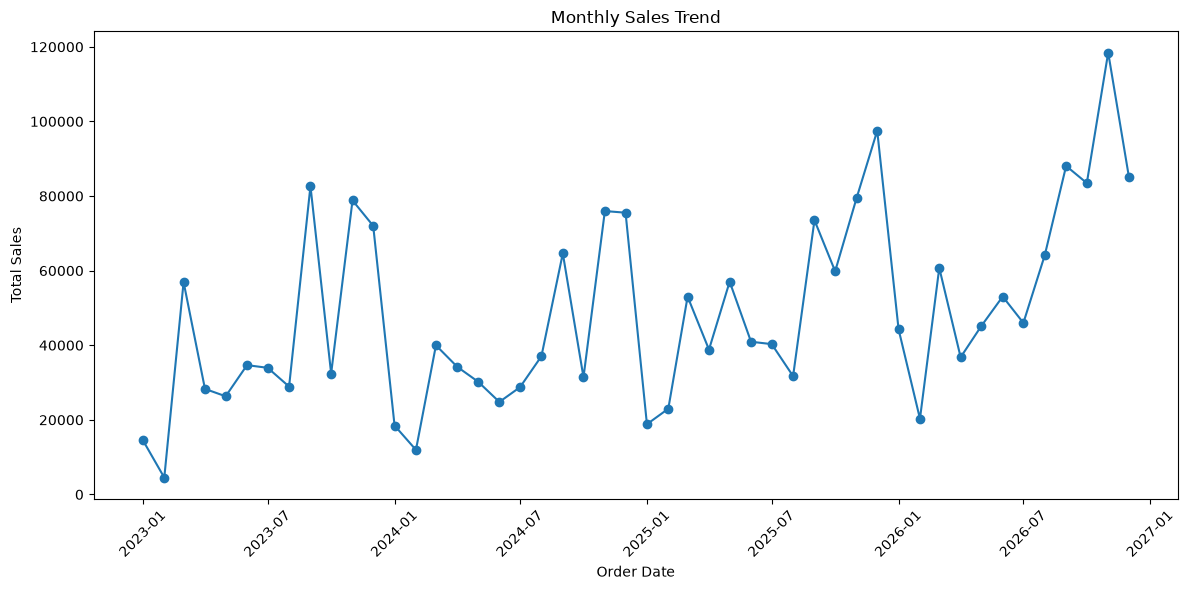

In [21]:
# Line Chart: Monthly Sales Trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/matplotlib/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Line Chart Interpretation

The line chart shows the monthly Sales trend over time. Sales fluctuate considerably from month to month, with several periods of high sales followed by noticeable declines.

The highest sales peak occurs toward the later part of the observed period, while some months have substantially lower sales. Overall, the chart indicates that Sales are variable over time and may be influenced by seasonal or business-related factors.

In [22]:
# Calculate total Sales by Category

category_sales = df.groupby("Category")["Sales"].sum()

category_sales

Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64

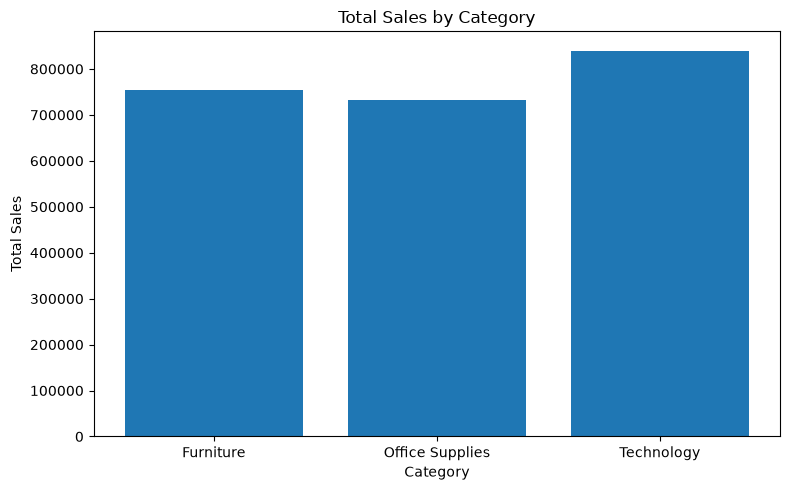

In [23]:
# Bar Chart: Sales by Category

plt.figure(figsize=(8, 5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig(
    "../visualizations/matplotlib/sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Bar Chart Interpretation

The bar chart compares total Sales across the three product categories.

Technology generates the highest total Sales, followed by Furniture, while Office Supplies has the lowest total Sales among the three categories.

This indicates that Technology is the strongest category in terms of overall Sales and may represent an important area for business growth and investment.

In [24]:
# Count orders by Category

category_orders = df["Category"].value_counts()

category_orders

Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

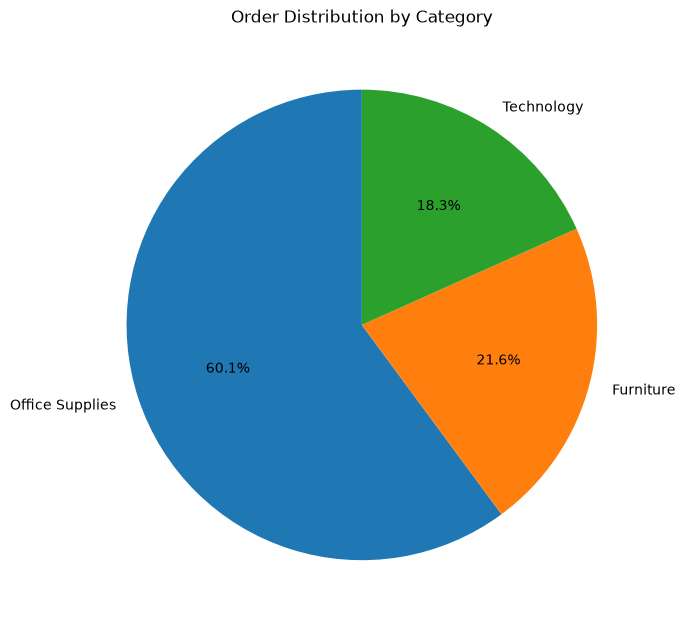

In [25]:
# Pie Chart: Order Distribution by Category

plt.figure(figsize=(7, 7))

plt.pie(
    category_orders.values,
    labels=category_orders.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Order Distribution by Category")

plt.tight_layout()

plt.savefig(
    "../visualizations/matplotlib/order_distribution_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Pie Chart Interpretation

The pie chart shows the distribution of orders across the three product categories.

Office Supplies accounts for the largest share of orders at **60.1%**, followed by Furniture at **21.6%** and Technology at **18.3%**.

Although Technology represents only 18.3% of the total orders, it generates the highest total Sales according to the bar chart. This suggests that Technology orders may have a higher average order value compared with the other categories.

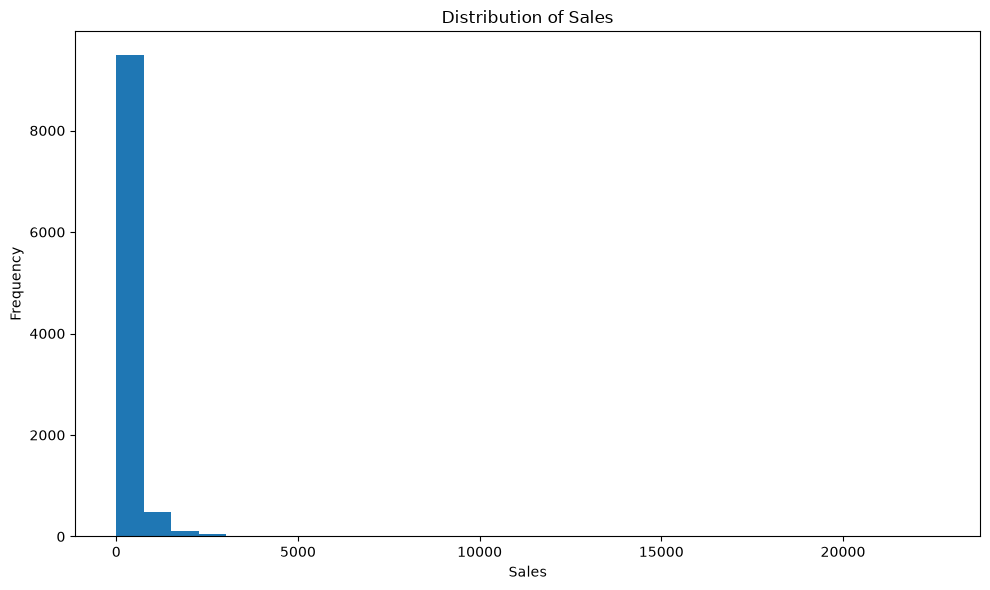

In [26]:
# Histogram: Distribution of Sales

plt.figure(figsize=(10, 6))

plt.hist(
    df["Sales"],
    bins=30
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../visualizations/matplotlib/sales_distribution_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Histogram Interpretation

The histogram shows the distribution of Sales values. Most orders are concentrated in the lower Sales range, while a relatively small number of orders have substantially higher Sales values.

The distribution is strongly **right-skewed**, with a long tail extending toward higher Sales values. This pattern is consistent with the difference between the mean Sales value (**228.23**) and median Sales value (**53.91**) identified in Task 1.

The histogram also supports the IQR outlier analysis from Task 4, where high-value Sales transactions were identified as potential outliers.

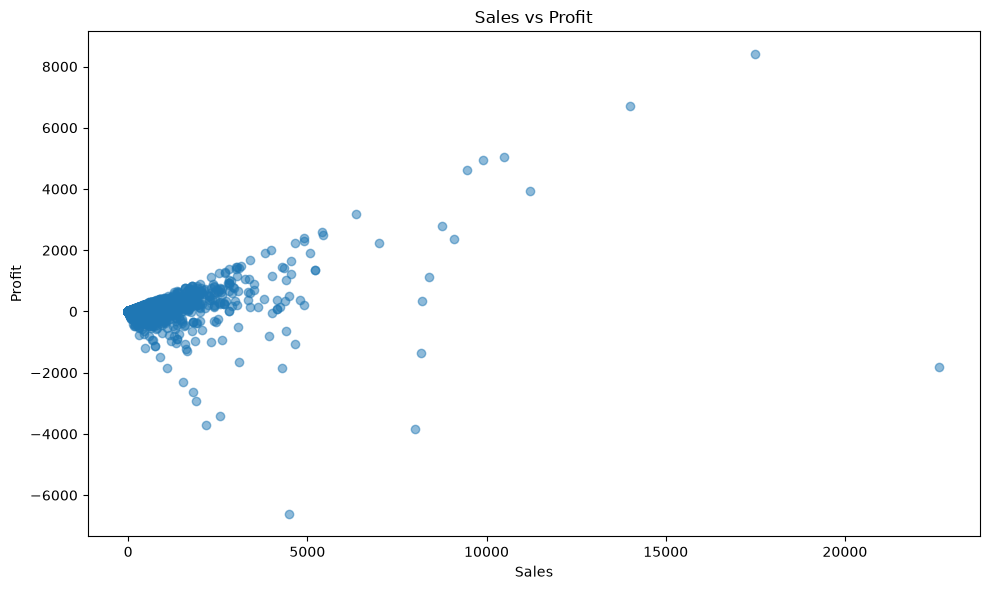

In [27]:
# Scatter Plot: Sales vs Profit

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.5
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    "../visualizations/matplotlib/sales_vs_profit_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Scatter Plot Interpretation

The scatter plot shows the relationship between Sales and Profit.

The points show a general upward trend, indicating that higher Sales values tend to be associated with higher Profit values. However, the points are widely dispersed and several unusual observations are present.

This visual pattern is consistent with the correlation coefficient of **0.4815**, which indicates a **moderate positive relationship** between Sales and Profit.

The presence of observations with high Sales but negative Profit also indicates that higher Sales do not always guarantee higher Profit.

# Task 6: Seaborn Visualizations

## Objective

Seaborn was used to create four visualizations to explore categorical distributions, profit variability, relationships between numerical variables, and correlations within the Superstore dataset.

The visualizations include a Count Plot, Box Plot, Heatmap, and Pair Plot.

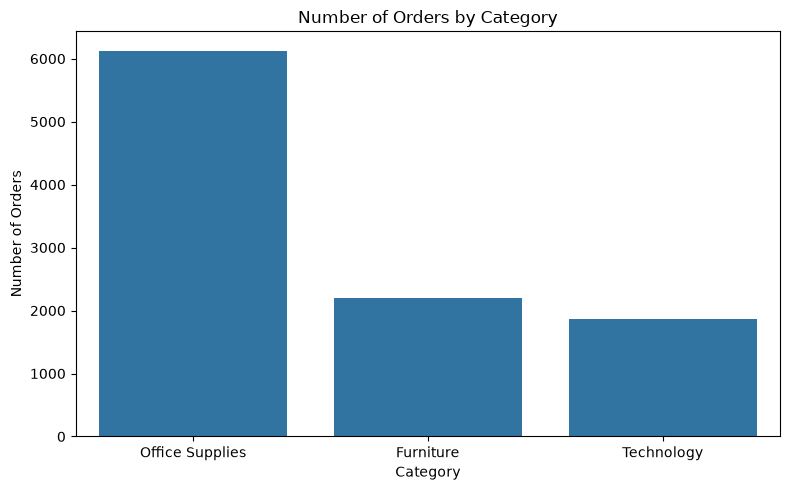

In [28]:
# Count Plot: Number of Orders by Category

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Category")

plt.title("Number of Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../visualizations/seaborn/orders_by_category_countplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Count Plot Interpretation

The Count Plot shows the number of orders in each product category.

Office Supplies has the highest number of orders, accounting for approximately **60.1%** of all orders. Furniture accounts for approximately **21.6%**, while Technology accounts for **18.3%**.

This indicates that Office Supplies has the highest order volume in the dataset, while Technology has the lowest number of orders among the three categories.

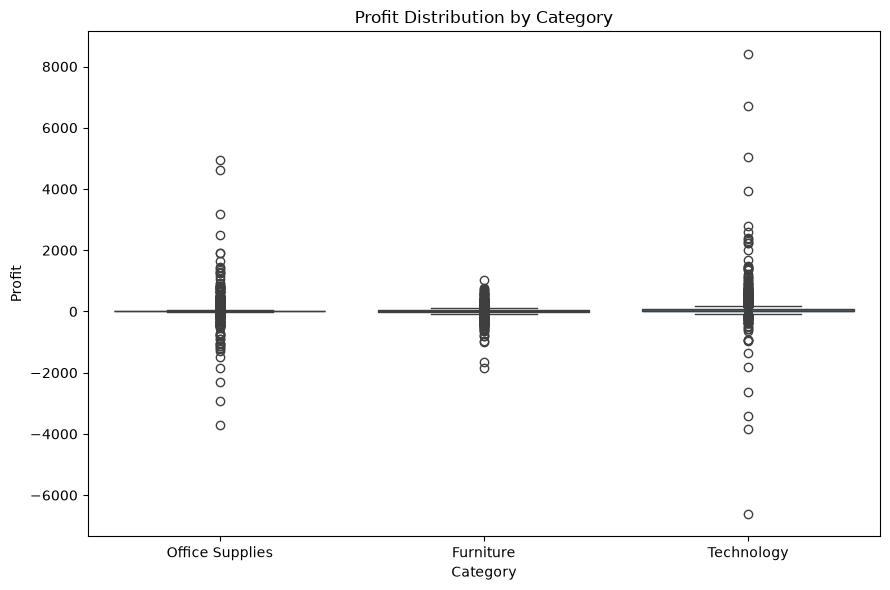

In [29]:
# Box Plot: Profit Distribution by Category

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Profit"
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    "../visualizations/seaborn/profit_by_category_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Box Plot Interpretation

The box plot shows the distribution of Profit across Furniture, Office Supplies, and Technology.

All three categories contain a number of potential Profit outliers, with both unusually high positive and negative Profit values. Technology shows some particularly extreme Profit observations compared with the other categories.

The presence of these extreme values indicates considerable variability in Profit. However, these observations should not automatically be removed because they may represent legitimate business transactions.

In [30]:
# Select numerical variables for correlation analysis

numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.198457,-0.027756,0.481460
Quantity,0.198457,1.000000,0.007475,0.066145
Discount,-0.027756,0.007475,1.000000,-0.218882
Profit,0.481460,0.066145,-0.218882,1.000000


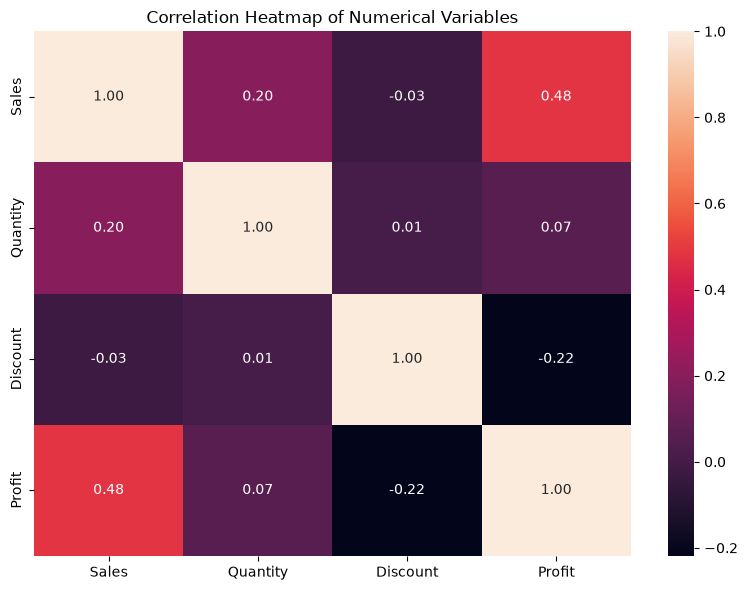

In [31]:
# Heatmap: Correlation between Numerical Variables

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()

plt.savefig(
    "../visualizations/seaborn/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Heatmap Interpretation

The correlation heatmap shows the relationships among Sales, Quantity, Discount, and Profit.

The strongest positive relationship is between **Sales and Profit**, with a correlation of approximately **0.48**, indicating a moderate positive relationship. This confirms the correlation analysis performed in Task 3.

The relationship between **Discount and Profit is -0.22**, indicating a weak negative relationship. This suggests that higher Discount levels tend to be associated with lower Profit, although the relationship is not strong.

Sales and Quantity have a weak positive correlation of **0.20**, while Quantity and Profit have a very weak positive correlation of **0.07**.

Sales and Discount have a correlation of **-0.03**, indicating almost no linear relationship between these variables.

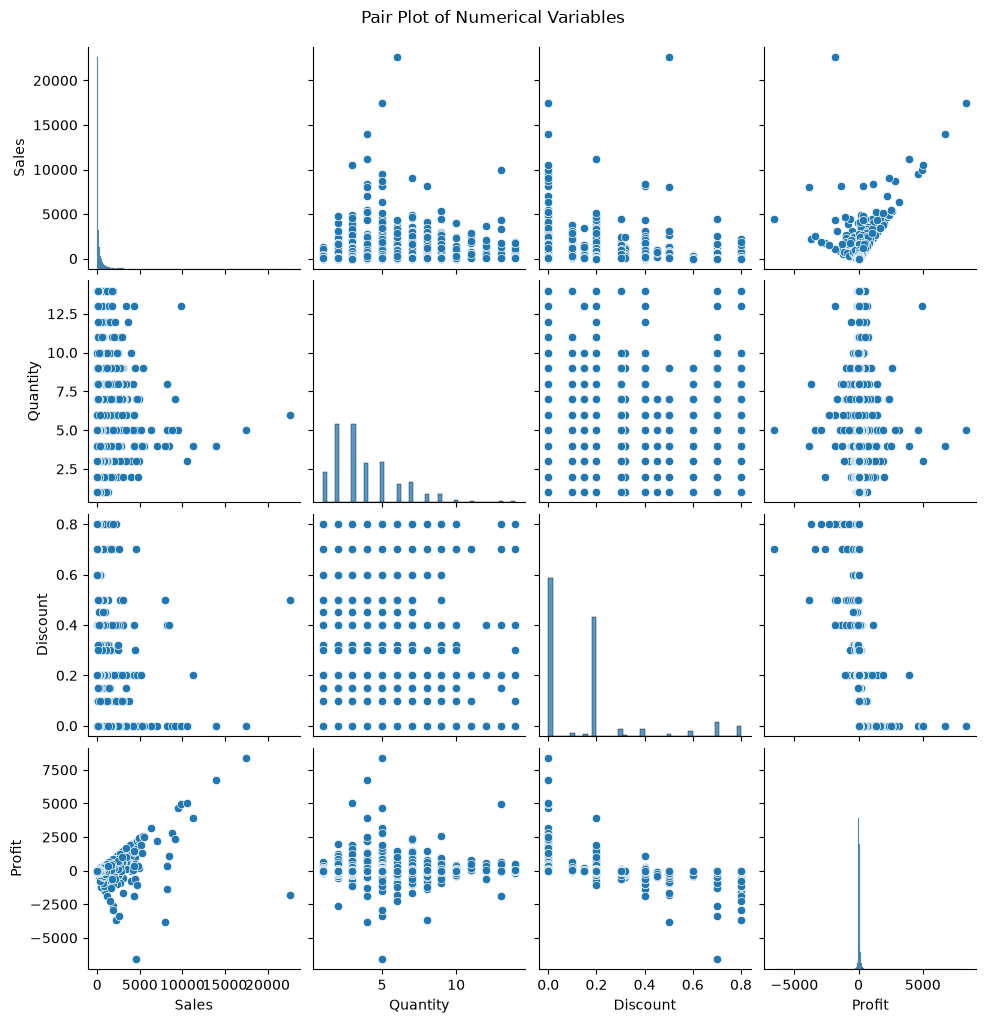

In [32]:
# Pair Plot: Relationships between Numerical Variables

pairplot = sns.pairplot(
    df[numeric_columns]
)

pairplot.fig.suptitle(
    "Pair Plot of Numerical Variables",
    y=1.02
)

pairplot.fig.savefig(
    "../visualizations/seaborn/numerical_variables_pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Pair Plot Interpretation

The Pair Plot provides a visual comparison of the relationships among Sales, Quantity, Discount, and Profit.

The most noticeable relationship is between **Sales and Profit**, where the points show a general positive trend. This is consistent with the correlation coefficient of approximately **0.48** observed in the heatmap.

The plot also shows that Sales and Profit contain extreme observations, while Quantity is concentrated around relatively small integer values. Discount appears at several distinct levels rather than being continuously distributed.

Overall, the Pair Plot supports the correlation analysis and provides a broader view of the relationships and distributions among the numerical variables.

# Task 7: Exploratory Data Analysis – Data Inspection & Cleaning

## Objective

Inspect the Superstore dataset, identify missing values, duplicate records, incorrect or inconsistent values, and perform appropriate data cleaning while preserving the original dataset for comparison.

In [33]:
# Create separate raw and cleaned DataFrames

df_raw = df.copy()
df_clean = df.copy()

print("Raw and cleaned DataFrames created successfully.")

Raw and cleaned DataFrames created successfully.


In [34]:
# Check the number of rows and columns

rows, columns = df_clean.shape

print("Number of Rows   :", rows)
print("Number of Columns:", columns)

Number of Rows   : 10194
Number of Columns: 21


In [35]:
# Display column names

print("Column Names:")
print("-" * 40)

for column in df_clean.columns:
    print(column)

Column Names:
----------------------------------------
Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country/Region
City
State/Province
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


In [36]:
# Check data types of all columns

print("Data Types:")
print("-" * 40)

print(df_clean.dtypes)

Data Types:
----------------------------------------
Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code               object
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object


In [37]:
# Generate statistical summary

df_clean.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [38]:
# Display the dataset before cleaning

df_raw.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
5,6,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.820,9,0.0,746.4078
6,7,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420,South,OFF-AR-10001662,Office Supplies,Art,Rogers Handheld Barrel Pencil Sharpener,5.480,2,0.0,1.4796
7,8,US-2023-106054,2023-01-06,2023-01-07,First Class,JO-15145,Jack O'Briant,Corporate,United States,Athens,Georgia,30605,South,OFF-AR-10002399,Office Supplies,Art,"Dixon Prang Watercolor Pencils, 10-Color Set w...",12.780,3,0.0,5.2398
8,9,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,609.980,2,0.0,274.4910
9,10,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420,South,OFF-FA-10001883,Office Supplies,Fasteners,"Alliance Super-Size Bands, Assorted Sizes",31.120,4,0.0,0.3112


In [39]:
# Check for missing values

missing_values = df_clean.isnull().sum()

print("Missing Values by Column")
print("-" * 40)
print(missing_values)

Missing Values by Column
----------------------------------------
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [40]:
# Calculate total number of missing values

total_missing = df_clean.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Total Missing Values: 0


In [41]:
# Check for duplicate records

duplicate_count = df_clean.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [42]:
# Check whether Order IDs are duplicated

if "Order ID" in df_clean.columns:
    duplicate_order_ids = df_clean["Order ID"].duplicated().sum()
    print("Duplicate Order IDs:", duplicate_order_ids)
else:
    print("Order ID column not found.")

Duplicate Order IDs: 5083


In [43]:
# Check minimum values of numerical columns

numeric_columns = df_clean.select_dtypes(include=np.number).columns

print("Minimum Values")
print("-" * 40)

print(df_clean[numeric_columns].min())

Minimum Values
----------------------------------------
Row ID         1.000
Sales          0.444
Quantity       1.000
Discount       0.000
Profit     -6599.978
dtype: float64


In [44]:
# Check Discount range

print("Minimum Discount:", df_clean["Discount"].min())
print("Maximum Discount:", df_clean["Discount"].max())

Minimum Discount: 0.0
Maximum Discount: 0.8


In [45]:
# Count invalid Discount values

invalid_discount = df_clean[
    (df_clean["Discount"] < 0) |
    (df_clean["Discount"] > 1)
]

print("Invalid Discount Records:", len(invalid_discount))

Invalid Discount Records: 0


In [46]:
# Check for invalid Quantity values

invalid_quantity = df_clean[
    df_clean["Quantity"] <= 0
]

print("Invalid Quantity Records:", len(invalid_quantity))

Invalid Quantity Records: 0


In [47]:
# Check for negative Sales values

negative_sales = df_clean[
    df_clean["Sales"] < 0
]

print("Negative Sales Records:", len(negative_sales))

Negative Sales Records: 0


In [48]:
# Check unique Category values

print("Unique Category Values:")
print(df_clean["Category"].unique())

Unique Category Values:
<StringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str


In [49]:
# Step 2: Safely standardize text columns

# Identify object-type columns without triggering Pandas warnings
text_columns = df_clean.columns[df_clean.dtypes == "object"]

for column in text_columns:
    df_clean[column] = df_clean[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Text standardization completed successfully.")

Text standardization completed successfully.


In [50]:
# Basic data cleaning

# Remove completely duplicated rows
df_clean = df_clean.drop_duplicates()

# Remove leading/trailing spaces from text columns
for column in text_columns:
    df_clean[column] = df_clean[column].astype(str).str.strip()

print("Basic cleaning completed.")

Basic cleaning completed.


In [51]:
import pandas as pd

# Load the dataset
df = pd.read_excel("../dataset/super_store.xls", sheet_name="Orders")

# Basic dataset information
rows = df.shape[0]
columns = df.shape[1]

# Missing values
missing_values = df.isnull().sum()
total_missing = df.isnull().sum().sum()

# Duplicate records
duplicate_records = df.duplicated().sum()

# Duplicate Order IDs
duplicate_order_ids = df["Order ID"].duplicated().sum()

# Invalid Discount Records
invalid_discount_records = ((df["Discount"] < 0) | (df["Discount"] > 1)).sum()

# Invalid Quantity Records
invalid_quantity_records = (df["Quantity"] <= 0).sum()

# Negative Sales Records
negative_sales_records = (df["Sales"] < 0).sum()

# Unique Category Values
unique_category_values = df["Category"].unique()

# Print results
print("Rows:", rows)
print("Columns:", columns)

print("\nMissing Values:")
print(missing_values)
print("Total Missing:", total_missing)

print("\nDuplicate Records:", duplicate_records)

print("Duplicate Order IDs:", duplicate_order_ids)

print("Invalid Discount Records:", invalid_discount_records)

print("Invalid Quantity Records:", invalid_quantity_records)

print("Negative Sales Records:", negative_sales_records)

print("Unique Category Values:", unique_category_values)

Rows: 10194
Columns: 21

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64
Total Missing: 0

Duplicate Records: 0
Duplicate Order IDs: 5083
Invalid Discount Records: 0
Invalid Quantity Records: 0
Negative Sales Records: 0
Unique Category Values: <StringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str


In [52]:
# Create a fresh cleaned copy from the raw dataset

df_clean = df_raw.copy()

print("Cleaned DataFrame created from raw data.")

Cleaned DataFrame created from raw data.


In [53]:
# Step 2: Safely standardize text columns

text_columns = df_clean.select_dtypes(
    include=["object", "string"]
).columns

for column in text_columns:
    df_clean[column] = df_clean[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Text standardization completed successfully.")

Text standardization completed successfully.


In [54]:
# Convert date columns to datetime format

df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

print("Date columns converted to datetime format.")

Date columns converted to datetime format.


In [55]:
# Verify the cleaned dataset

print("AFTER CLEANING")
print("=" * 40)

print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("Total Missing Values:", df_clean.isnull().sum().sum())
print("Duplicate Records:", df_clean.duplicated().sum())

print("Negative Sales:", (df_clean["Sales"] < 0).sum())
print("Invalid Quantity:", (df_clean["Quantity"] <= 0).sum())
print(
    "Invalid Discount:",
    ((df_clean["Discount"] < 0) | (df_clean["Discount"] > 1)).sum()
)

AFTER CLEANING
Rows: 10194
Columns: 21
Total Missing Values: 0
Duplicate Records: 0
Negative Sales: 0
Invalid Quantity: 0
Invalid Discount: 0


In [56]:
# Dataset after cleaning

df_clean.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840
5,6,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420,South,FUR-CH-10004063,Furniture,Chairs,Global Deluxe High-Back Manager's Chair,2573.820,9,0.0,746.4078
6,7,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420,South,OFF-AR-10001662,Office Supplies,Art,Rogers Handheld Barrel Pencil Sharpener,5.480,2,0.0,1.4796
7,8,US-2023-106054,2023-01-06,2023-01-07,First Class,JO-15145,Jack O'Briant,Corporate,United States,Athens,Georgia,30605,South,OFF-AR-10002399,Office Supplies,Art,"Dixon Prang Watercolor Pencils, 10-Color Set w...",12.780,3,0.0,5.2398
8,9,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420,South,OFF-BI-10004632,Office Supplies,Binders,Ibico Hi-Tech Manual Binding System,609.980,2,0.0,274.4910
9,10,US-2023-167199,2023-01-06,2023-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,Kentucky,42420,South,OFF-FA-10001883,Office Supplies,Fasteners,"Alliance Super-Size Bands, Assorted Sizes",31.120,4,0.0,0.3112


## Task 7 Interpretation

### Data Inspection

The Superstore dataset contains **10,194 rows and 21 columns**. The dataset was inspected by checking its dimensions, column names, data types, and statistical summary.

### Data Quality Findings

The dataset contains **0 missing values** and **0 completely duplicated records**. Therefore, no missing-value imputation or duplicate-row removal was required.

There are **5,083 duplicate Order IDs**, but these were not removed because repeated Order IDs can represent multiple product line items belonging to the same order. The presence of repeated Order IDs does not necessarily indicate duplicate records.

The dataset contains **0 invalid Discount records**, **0 invalid Quantity records**, and **0 negative Sales records**. The Category column contains three consistent values: Furniture, Office Supplies, and Technology.

### Data Cleaning

The cleaned dataset was created as a separate copy of the raw dataset. Text columns were standardized by removing unnecessary leading and trailing spaces, and the Order Date and Ship Date columns were converted to the appropriate datetime format.

After cleaning, the dataset retained **10,194 rows and 21 columns**, confirming that no valid records were unnecessarily removed.

### Before and After Cleaning

Screenshots of the dataset before and after cleaning are included to document the data-cleaning process.

In [57]:
# Check data types after cleaning

df_clean.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code               object
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [58]:
# Verify Postal Code values before and after cleaning

print("Missing Postal Codes Before Cleaning:",
      df_raw["Postal Code"].isnull().sum())

print("Missing Postal Codes After Cleaning:",
      df_clean["Postal Code"].isnull().sum())

Missing Postal Codes Before Cleaning: 0
Missing Postal Codes After Cleaning: 0


In [59]:
# Check the Postal Code data type

print("Postal Code Data Type:")
print(df_clean["Postal Code"].dtype)

Postal Code Data Type:
object


In [60]:
# Final cleaned dataset verification

print("FINAL CLEANED DATASET")
print("=" * 45)

print(f"Rows                  : {df_clean.shape[0]}")
print(f"Columns               : {df_clean.shape[1]}")
print(f"Missing Values        : {df_clean.isnull().sum().sum()}")
print(f"Duplicate Records     : {df_clean.duplicated().sum()}")
print(f"Invalid Discount      : {((df_clean['Discount'] < 0) | (df_clean['Discount'] > 1)).sum()}")
print(f"Invalid Quantity      : {(df_clean['Quantity'] <= 0).sum()}")
print(f"Negative Sales        : {(df_clean['Sales'] < 0).sum()}")

FINAL CLEANED DATASET
Rows                  : 10194
Columns               : 21
Missing Values        : 0
Duplicate Records     : 0
Invalid Discount      : 0
Invalid Quantity      : 0
Negative Sales        : 0


In [61]:
# Reset the cleaned dataset from the original raw dataset

df_clean = df_raw.copy()

print("Cleaned dataset reset from raw dataset.")

Cleaned dataset reset from raw dataset.


In [62]:
# Inspect Postal Code values and data type

print("Postal Code Data Type:", df_clean["Postal Code"].dtype)
print()
print("First 10 Postal Code values:")
print(df_clean["Postal Code"].head(10))
print()
print("Actual missing Postal Codes:")
print(df_clean["Postal Code"].isna().sum())

Postal Code Data Type: object

First 10 Postal Code values:
0    77095
1    60540
2    60540
3    60540
4    19143
5    42420
6    42420
7    30605
8    42420
9    42420
Name: Postal Code, dtype: object

Actual missing Postal Codes:
0


In [63]:
# Check how Postal Code values are represented

print("Number of unique Postal Code values:")
print(df_clean["Postal Code"].nunique(dropna=False))

print("\nSample unique Postal Code values:")
print(df_clean["Postal Code"].unique()[:20])

Number of unique Postal Code values:
654

Sample unique Postal Code values:
[77095 60540 19143 42420 30605 90049 77340 78041 22153 19901 94109 29464
 43055 71111 19140 30076 19134 97477 85254 72401]


In [64]:
# Final verification of the cleaned dataset

print("FINAL CLEANED DATASET")
print("=" * 50)

print(f"Rows                  : {df_clean.shape[0]}")
print(f"Columns               : {df_clean.shape[1]}")
print(f"Missing Values        : {df_clean.isnull().sum().sum()}")
print(f"Duplicate Records     : {df_clean.duplicated().sum()}")

print(
    f"Invalid Discount     : "
    f"{((df_clean['Discount'] < 0) | (df_clean['Discount'] > 1)).sum()}"
)

print(
    f"Invalid Quantity     : "
    f"{(df_clean['Quantity'] <= 0).sum()}"
)

print(
    f"Negative Sales       : "
    f"{(df_clean['Sales'] < 0).sum()}"
)

print(
    f"Missing Postal Codes : "
    f"{df_clean['Postal Code'].isna().sum()}"
)

FINAL CLEANED DATASET
Rows                  : 10194
Columns               : 21
Missing Values        : 0
Duplicate Records     : 0
Invalid Discount     : 0
Invalid Quantity     : 0
Negative Sales       : 0
Missing Postal Codes : 0


## Task 7 Interpretation

### Data Inspection

The Superstore dataset contains **10,194 rows and 21 columns**. The dataset was inspected by checking its dimensions, column names, data types, and statistical summary.

### Data Quality Findings

The dataset contains **0 missing values** and **0 completely duplicated records**. Therefore, no missing-value imputation or duplicate-row removal was required.

There are **5,083 repeated Order IDs**, but these were retained because one order can contain multiple product line items. Repeated Order IDs therefore do not necessarily represent duplicate records.

The dataset contains **0 invalid Discount records**, **0 invalid Quantity records**, and **0 negative Sales records**.

The Category column contains three valid and consistent categories:

- Furniture
- Office Supplies
- Technology

### Data Cleaning

A separate cleaned copy of the dataset was created from the raw dataset.

Text fields were safely standardized by removing unnecessary leading and trailing spaces while preserving non-text values. The Order Date and Ship Date columns were converted to the appropriate datetime format.

Postal Code values were preserved because they were valid and contained **0 actual missing values**.

After cleaning, the dataset retained **10,194 rows and 21 columns**, with **0 missing values and 0 duplicate records**.

### Before and After Cleaning

Screenshots of the dataset before and after cleaning are included to document the cleaning process.

# Task 8: EDA – Correlation & Insights

## Objective

The objective of this analysis is to identify important relationships, patterns, and trends within the Superstore dataset using correlation analysis and supporting visualizations.

In [65]:
# Correlation analysis of numerical variables

numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]

correlation_matrix = df_clean[numeric_columns].corr()

print("Correlation Matrix")
print("=" * 50)

print(correlation_matrix.round(4))

Correlation Matrix
           Sales  Quantity  Discount  Profit
Sales     1.0000    0.1985   -0.0278  0.4815
Quantity  0.1985    1.0000    0.0075  0.0661
Discount -0.0278    0.0075    1.0000 -0.2189
Profit    0.4815    0.0661   -0.2189  1.0000


In [66]:
# Find the strongest correlations between different variables

corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().sort_values(
    key=abs,
    ascending=False
)

print("Correlation Pairs Ranked by Strength")
print("=" * 50)

print(corr_pairs.round(4))

Correlation Pairs Ranked by Strength
Sales     Profit      0.4815
Discount  Profit     -0.2189
Sales     Quantity    0.1985
Quantity  Profit      0.0661
Sales     Discount   -0.0278
Quantity  Discount    0.0075
Sales     Sales          NaN
Quantity  Sales          NaN
          Quantity       NaN
Discount  Sales          NaN
          Quantity       NaN
          Discount       NaN
Profit    Sales          NaN
          Quantity       NaN
          Discount       NaN
          Profit         NaN
dtype: float64


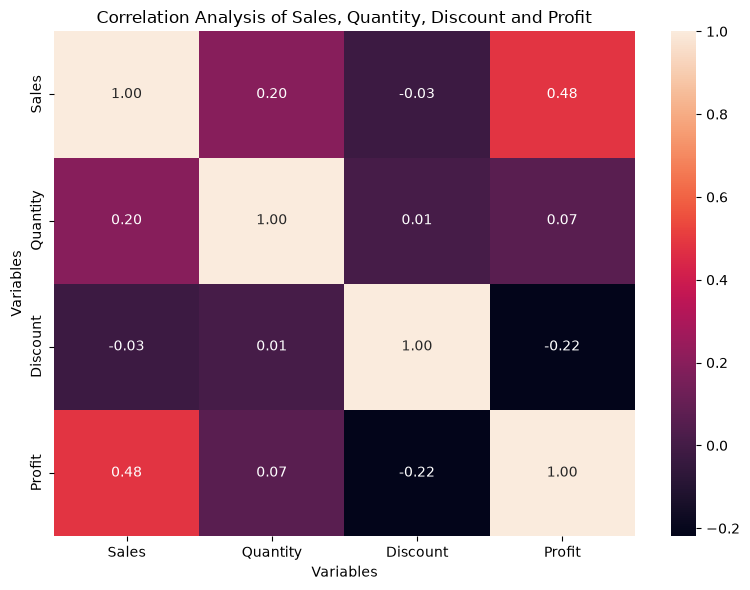

In [67]:
# Task 8: Correlation Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Analysis of Sales, Quantity, Discount and Profit")
plt.xlabel("Variables")
plt.ylabel("Variables")

plt.tight_layout()

plt.savefig(
    "../visualizations/seaborn/task8_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
# Sales vs Profit correlation

sales_profit_corr = df_clean["Sales"].corr(df_clean["Profit"])

print(f"Sales vs Profit Correlation: {sales_profit_corr:.4f}")

if sales_profit_corr > 0:
    print("Relationship: Positive")
elif sales_profit_corr < 0:
    print("Relationship: Negative")
else:
    print("Relationship: No linear relationship")

Sales vs Profit Correlation: 0.4815
Relationship: Positive


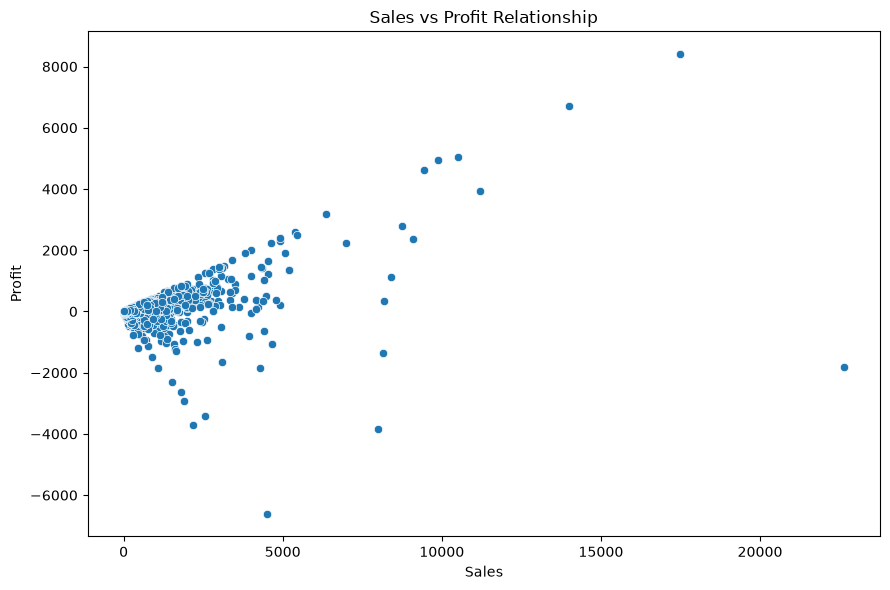

In [69]:
# Sales vs Profit relationship

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Sales",
    y="Profit"
)

plt.title("Sales vs Profit Relationship")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    "../visualizations/seaborn/task8_sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
# Discount vs Profit correlation

discount_profit_corr = df_clean["Discount"].corr(
    df_clean["Profit"]
)

print(f"Discount vs Profit Correlation: {discount_profit_corr:.4f}")

if discount_profit_corr > 0:
    print("Relationship: Positive")
elif discount_profit_corr < 0:
    print("Relationship: Negative")
else:
    print("Relationship: No linear relationship")

Discount vs Profit Correlation: -0.2189
Relationship: Negative


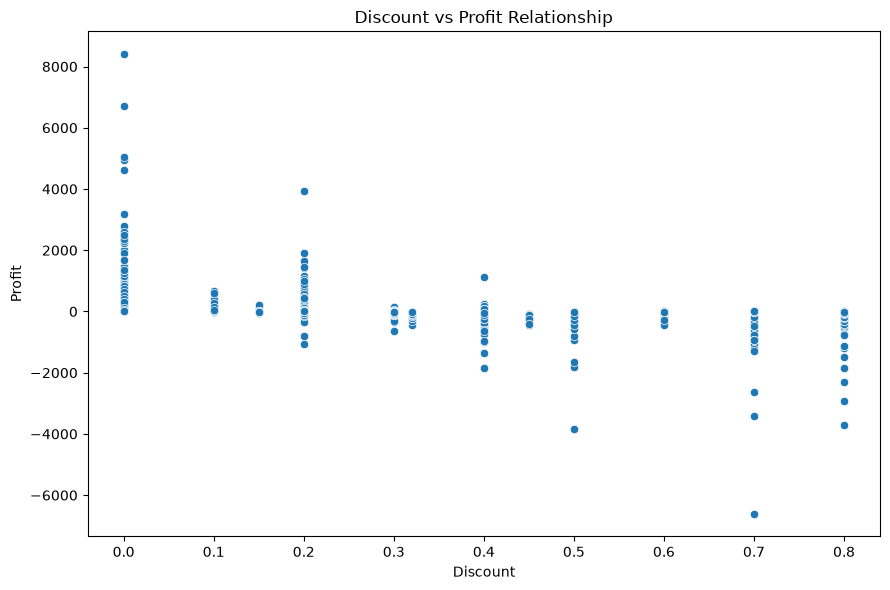

In [71]:
# Discount vs Profit relationship

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="Discount",
    y="Profit"
)

plt.title("Discount vs Profit Relationship")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig(
    "../visualizations/seaborn/task8_discount_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
# Calculate total Sales and Profit by Category

category_analysis = df_clean.groupby("Category")[
    ["Sales", "Profit"]
].sum().sort_values(
    "Sales",
    ascending=False
)

print("Sales and Profit by Category")
print("=" * 50)

print(category_analysis.round(2))

Sales and Profit by Category
                     Sales     Profit
Category                             
Technology       839893.28  146543.38
Furniture        754747.76   19730.00
Office Supplies  731893.31  126023.44


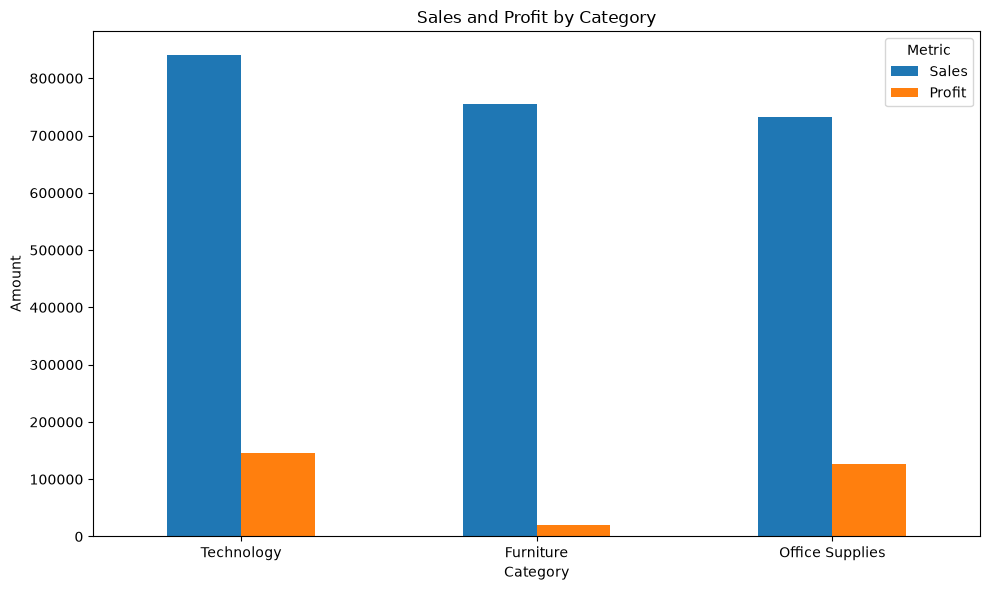

In [73]:
# Category-level Sales and Profit

category_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()

plt.savefig(
    "../visualizations/matplotlib/task8_category_sales_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
# Calculate profit margin by category

category_summary = df_clean.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

category_summary["Profit_Margin_%"] = (
    category_summary["Total_Profit"] /
    category_summary["Total_Sales"]
) * 100

print("Category Performance")
print("=" * 60)

print(category_summary.round(2))

Category Performance
                 Total_Sales  Total_Profit  Profit_Margin_%
Category                                                   
Furniture          754747.76      19730.00             2.61
Office Supplies    731893.31     126023.44            17.22
Technology         839893.28     146543.38            17.45


In [75]:
# Identify the category with the highest profit

most_profitable_category = category_summary[
    "Total_Profit"
].idxmax()

highest_profit = category_summary[
    "Total_Profit"
].max()

print("Most Profitable Category:", most_profitable_category)
print(f"Total Profit: {highest_profit:.2f}")

Most Profitable Category: Technology
Total Profit: 146543.38


In [76]:
# Identify the category with the highest Sales

highest_sales_category = category_summary[
    "Total_Sales"
].idxmax()

highest_sales = category_summary[
    "Total_Sales"
].max()

print("Highest Sales Category:", highest_sales_category)
print(f"Total Sales: {highest_sales:.2f}")

Highest Sales Category: Technology
Total Sales: 839893.28


In [77]:
# Calculate average Sales per order record by category

category_order_analysis = df_clean.groupby("Category").agg(
    Orders=("Order ID", "count"),
    Total_Sales=("Sales", "sum")
)

category_order_analysis["Average_Sales_Per_Order"] = (
    category_order_analysis["Total_Sales"] /
    category_order_analysis["Orders"]
)

print("Average Sales per Order by Category")
print("=" * 60)

print(category_order_analysis.round(2))

Average Sales per Order by Category
                 Orders  Total_Sales  Average_Sales_Per_Order
Category                                                     
Furniture          2201    754747.76                   342.91
Office Supplies    6128    731893.31                   119.43
Technology         1865    839893.28                   450.34


# Task 8: EDA – Correlation & Insights

## Correlation Analysis

Correlation analysis was performed on the numerical variables Sales, Quantity, Discount, and Profit.

The strongest relationship was observed between **Sales and Profit**, with a correlation coefficient of **0.4815**, indicating a moderate positive relationship.

The relationship between **Discount and Profit** was **-0.2189**, indicating a weak negative relationship. This suggests that higher discount levels tend to be associated with lower Profit.

Sales and Quantity had a weak positive correlation of **0.1985**, while Quantity and Profit had a very weak positive correlation of **0.0661**. Sales and Discount had an almost negligible correlation of **-0.0278**.

## Key Insights

### Insight 1: Sales and Profit

Sales and Profit have a moderate positive correlation of **0.4815**. This indicates that higher Sales are generally associated with higher Profit. However, Sales alone do not determine profitability, as other factors such as discounts and product mix can also influence Profit.

### Insight 2: Discount and Profit

Discount and Profit have a weak negative correlation of **-0.2189**. This indicates that higher discount levels tend to be associated with lower Profit. The relationship is not strong, so discount is not the only factor influencing profitability.

### Insight 3: Technology is the Strongest Performing Category

Technology generates the highest total Sales of **839,893.28** and the highest total Profit of **146,543.38**. It also has the highest Profit Margin at **17.45%**, slightly higher than Office Supplies at **17.22%**.

### Insight 4: Furniture Has Low Profitability

Furniture generates **754,747.76** in Sales but only **19,730.00** in Profit, resulting in a Profit Margin of only **2.61%**. This is substantially lower than the margins of Technology and Office Supplies and indicates that Furniture profitability should be investigated.

### Insight 5: Technology Has the Highest Average Sales per Order

Technology has the highest Average Sales per Order at **538.39**, compared with **414.92** for Furniture and **192.00** for Office Supplies. This helps explain why Technology generates the highest total Sales despite representing a smaller proportion of total orders.

## Overall EDA Conclusion

The analysis shows that Sales and Profit have a moderate positive relationship, while higher Discount levels are associated with lower Profit. Technology is the strongest-performing category in terms of Sales, Profit, Profit Margin, and Average Sales per Order. In contrast, Furniture requires further investigation because it generates substantial Sales but has a significantly lower Profit Margin.

# Task 9: Business Recommendations

Based on the Exploratory Data Analysis, correlation analysis, category performance, and profitability analysis, the following data-driven business recommendations are proposed.

## Recommendation 1: Improve Furniture Profitability

The business should review the pricing, discounting, and cost structure of Furniture products.

Furniture generated **754,747.76** in Sales but only **19,730.00** in Profit, resulting in a Profit Margin of just **2.61%**. This is substantially lower than Technology (**17.45%**) and Office Supplies (**17.22%**).

The business should investigate product-level margins, supplier costs, pricing, discount levels, and products generating low or negative Profit. Improving Furniture margins could significantly increase overall profitability.

## Recommendation 2: Implement a More Controlled Discount Strategy

The business should use a more targeted discount strategy and carefully evaluate the profitability impact of large discounts.

The correlation between Discount and Profit is **-0.2189**, indicating a weak negative relationship. Higher discount levels tend to be associated with lower Profit.

Instead of applying broad discounts, the business could establish discount limits for low-margin products, evaluate profitability before promotions, and use targeted discounts for selected products or customer segments.

Correlation does not prove causation, so discount decisions should be evaluated together with product costs, pricing, and other business factors.

## Recommendation 3: Focus on High-Performing Technology Products

The business should identify and prioritize high-performing Technology products and explore opportunities to increase their sales while maintaining profitability.

Technology generated the highest total Sales (**839,893.28**), highest total Profit (**146,543.38**), and highest Profit Margin (**17.45%**). It also had the highest Average Sales per Order at **538.39**.

The business could support this category through targeted marketing, maintaining inventory availability, competitive pricing, and cross-selling opportunities.

## Overall Business Conclusion

The analysis indicates that Technology is currently the strongest-performing category, while Furniture requires significant attention because of its low Profit Margin. The negative association between Discount and Profit also suggests that discount strategies should be carefully monitored.

These recommendations are based on the observed Sales, Profit, Profit Margin, Average Sales per Order, and correlation results from the dataset.